# Reading the fitted system: energy, stability, networks

A fitted scHopfield system is not a single answer. The same $W$, $\Gamma$ and $I$ support three
different readings, and this tutorial derives all three from one fit without fitting anything
further:

- **Energy.** Where the system is comfortable, and which term of the model puts it there.
- **Stability.** Whether a cell sits in a state the dynamics hold it in, read from the Jacobian.
- **Networks.** Which regulators carry the field, and how much the regulatory program differs
  between cell types.

That the three come from one fit is the point. They are not three analyses of the data, they are
three views of one model of it.

**Runtime.** About two minutes on an RTX 3090: under fifteen seconds for the setup and the rest
in the analyses, of which the Jacobians are the largest single piece. A GPU is optional.

## Setup: rebuild the object and load the fitted model

This tutorial starts from the checkpoint written by **Getting started**. Run that notebook first,
or copy its `pancreas_fitted.h5sch` next to this one.

The checkpoint holds the model and not the experiment: the interaction matrices, the bias and
degradation vectors, and the activation parameters. It does not hold the expression data, so the
cell-level object is rebuilt here from the same public download and the same recipe. That part
costs well under a minute and runs on a CPU. What it saves is the interaction fit, which is the
one step that wants a GPU.

The activation comes back with the network. `save_model` writes both Hill components of every
gene and the weight that mixes them, so `compute_sigmoid` after `load_model` rebuilds the
**two-component** activation the system was fitted with rather than a single Hill curve standing
in for it. Nothing is re-fitted here.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv
import torch

import scHopfield as sch

scv.settings.verbosity = 0
sc.settings.verbosity = 0

CHECKPOINT = "pancreas_fitted.h5sch"
CLUSTER_KEY = "clusters"
ORDER = ["Ductal", "Ngn3 low EP", "Ngn3 high EP", "Pre-endocrine",
         "Alpha", "Beta", "Delta", "Epsilon"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"'{CHECKPOINT}' not found. Run the Getting started tutorial first: it fits the model "
        f"and writes this file.")

t0 = time.time()

# The same preparation as Getting started, section by section.
adata = scv.datasets.pancreas()
scv.pp.filter_genes(adata, min_shared_counts=20)
scv.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var["highly_variable"]].copy()
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.velocity(adata, mode="steady_state")

adata.layers["velocity_S"] = adata.layers["velocity"]
adata.var["gamma"] = adata.var["velocity_gamma"].astype(np.float32)
vel = np.asarray(adata.layers["velocity_S"])
keep = (np.isfinite(adata.var["gamma"].values)
        & np.isfinite(vel).all(axis=0)
        & (adata.var["gamma"].values > 0))
adata = adata[:, keep].copy()
adata.var["scHopfield_used"] = True

# Restore the fitted system from the checkpoint: the network and the activation both.
adata = sch.tl.load_model(adata, CHECKPOINT)
sch.pp.compute_sigmoid(adata, spliced_key="Ms")

print(f"setup: {time.time() - t0:.1f} s on a CPU")
print(adata.shape)
print("fitted systems:", sorted(k[2:] for k in adata.varp if k.startswith("W_")))

/tmp/ipykernel_4010943/2386655385.py:36: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
.../site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


Model loaded from 'pancreas_fitted.h5sch'  |  clusters=['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']  |  genes=2000


setup: 13.4 s on a CPU
(3696, 2000)
fitted systems: ['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']


The checkpoint and the rebuild have to describe the same genes in the same order, or the model
would be loaded onto the wrong ones. `load_model` raises if a gene the model needs is absent, and
warns if the file predates the activation being stored in full. Neither fires above, so the
activation in use is the fitted one, and it is worth seeing how much of it is genuinely
two-component.

In [2]:
n_bimodal = int((adata.var["sigmoid_mix"].values < 1 - 1e-9).sum())
print(f"activation fitted with two components: {adata.uns['scHopfield']['sigmoid_bimodal']}")
print(f"genes with a real second activation component: {n_bimodal} / {adata.n_vars}")

activation fitted with two components: True
genes with a real second activation component: 586 / 2000


## 1. Energy

The energy of a state is

$$E(x) = -\tfrac{1}{2}\,\sigma(x)^{\top} W \sigma(x)
        + \sum_i \gamma_i \!\int^{\sigma_i} \!\sigma_i^{-1}
        - I^{\top}\sigma(x),$$

three terms that `compute_energies` stores separately as well as summed:

| term | `adata.obs` column | what it measures |
| :-- | :-- | :-- |
| interaction | `energy_interaction` | how well the expressed genes reinforce each other |
| degradation | `energy_degradation` | the cost of holding expression away from zero |
| bias | `energy_bias` | what the constant drive contributes |

Each cell is scored under its own cell type's system.

In [3]:
t0 = time.time()
sch.tl.compute_energies(adata, cluster_key=CLUSTER_KEY)
print(f"energies: {time.time() - t0:.1f} s")

energy_cols = ["energy_total", "energy_interaction", "energy_degradation", "energy_bias"]
by_type = adata.obs.groupby(CLUSTER_KEY, observed=True)[energy_cols].mean().reindex(ORDER)
by_type["spread of total"] = (adata.obs.groupby(CLUSTER_KEY, observed=True)["energy_total"]
                              .std().reindex(ORDER))
by_type.round(2)

energies: 34.5 s


,energy_total,energy_interaction,energy_degradation,energy_bias,spread of total
clusters,,,,,
Ductal,35.96,-42.04,78.00,-0.0,11.64
Ngn3 low EP,39.93,-45.55,85.48,0.0,6.90
Ngn3 high EP,48.70,-79.35,128.05,-0.0,17.59
Pre-endocrine,106.25,-97.19,203.44,-0.0,14.94
Alpha,108.92,-85.78,194.70,-0.0,16.19
Beta,133.92,-80.93,214.84,-0.0,64.56
Delta,96.79,-92.08,188.87,-0.0,8.21
Epsilon,89.51,-81.65,171.16,0.0,13.54


Two things in that table are worth reading carefully, and both are properties of this fit rather
than of the plotting.

**The bias term is essentially zero.** It is not zero by construction: $I$ is a free parameter.
It is zero because the fit is restricted, a scaffold on $W$ and an L1 penalty on $I$, and the
restriction leaves the interaction and degradation terms to account for the energy. An
unrestricted fit does not behave this way, which is the subject of the scaffold tutorial.

**The interaction and degradation terms pull in opposite directions along development.** Both
grow in magnitude as cells differentiate. The mature endocrine types sit at strongly negative
interaction energy, meaning their expressed genes reinforce one another, while paying a larger
degradation cost to hold that expression up.

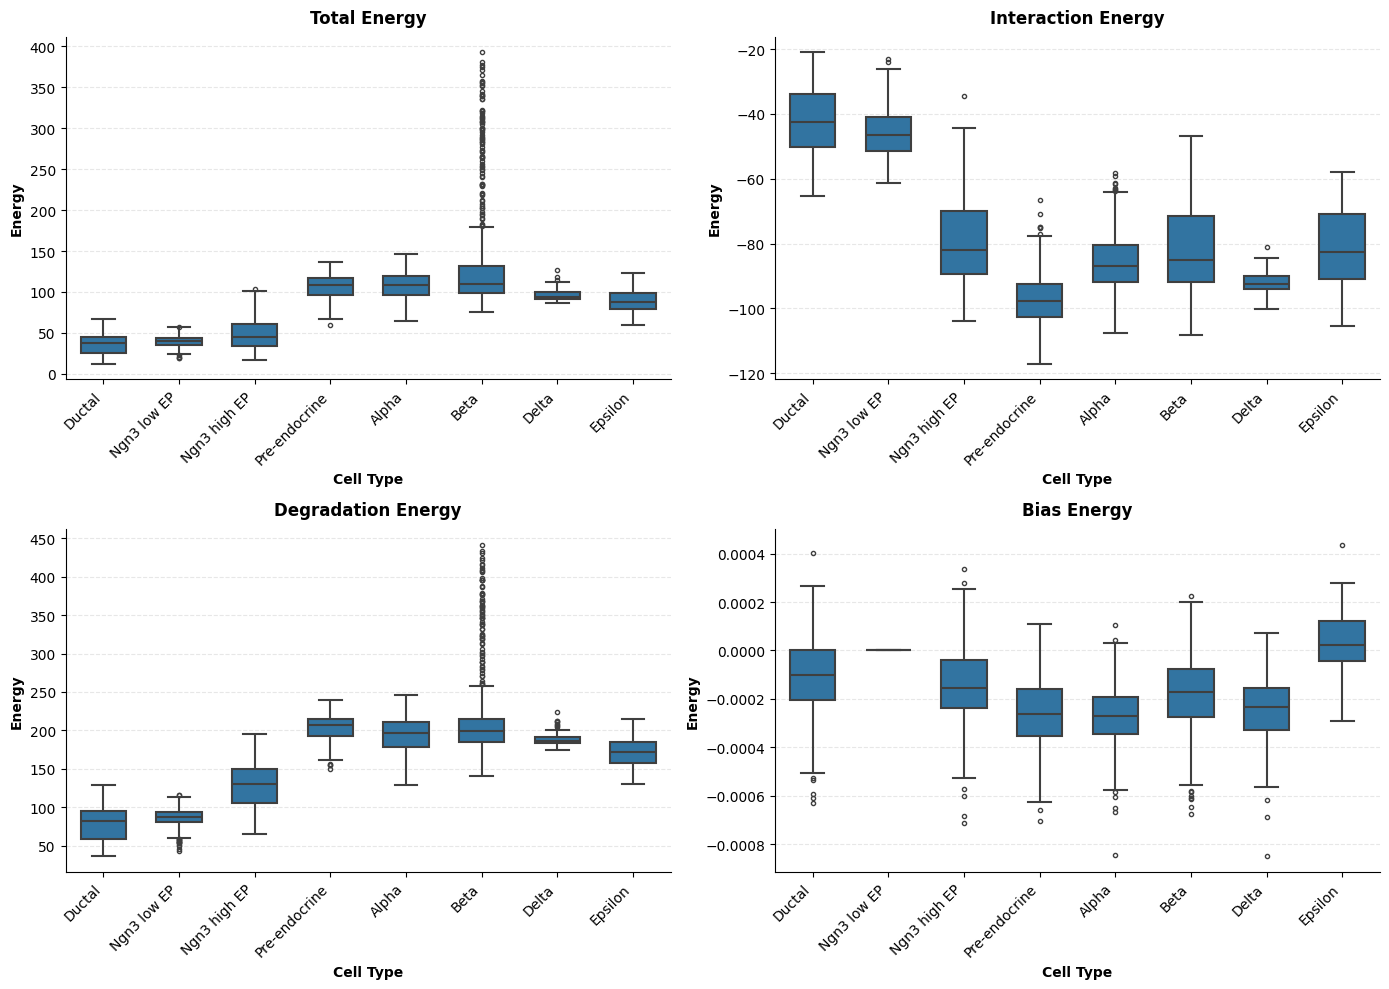

In [4]:
fig = sch.pl.plot_energy_boxplots(adata, cluster_key=CLUSTER_KEY, order=ORDER, plot_energy="all")
plt.show()

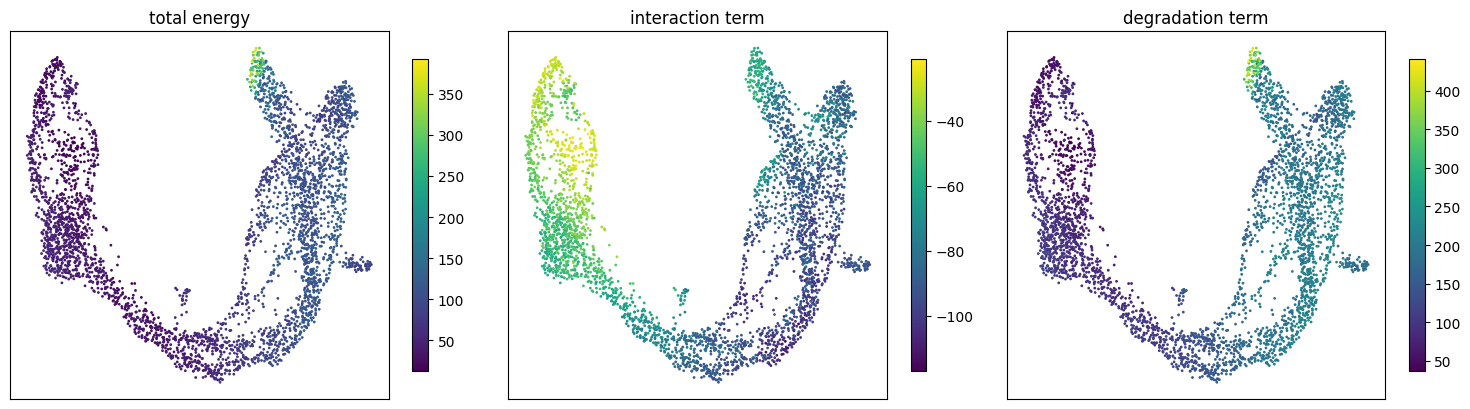

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, title in zip(
        axes,
        ["energy_total", "energy_interaction", "energy_degradation"],
        ["total energy", "interaction term", "degradation term"]):
    v = adata.obs[col].values
    sca = ax.scatter(adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1],
                     c=v, s=4, cmap="viridis", linewidths=0)
    fig.colorbar(sca, ax=ax, shrink=0.85)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## 2. Stability

The energy says where the system is comfortable. It does not say whether a cell is *held* there.
That is the Jacobian $J = \partial \dot{x} / \partial x$, evaluated per cell:

- every eigenvalue with a negative real part is a direction the dynamics pull back from,
- an eigenvalue with a positive real part is a direction they push away along, so a cell with any
  of those is not at rest,
- a complex pair is a rotation rather than a straight approach.

`compute_jacobians` evaluates one Jacobian per cell and stores its eigenvalues.
`compute_jacobian_stats` reduces them to per-cell summaries.

In [6]:
t0 = time.time()
sch.tl.compute_eigenanalysis(adata, cluster_key=CLUSTER_KEY)
sch.tl.compute_jacobians(adata, cluster_key=CLUSTER_KEY, device=DEVICE)
sch.tl.compute_jacobian_stats(adata)
print(f"\nJacobians and eigenvalues: {time.time() - t0:.1f} s on {DEVICE}")

stab = (adata.obs.groupby(CLUSTER_KEY, observed=True)
        [["jacobian_positive_evals", "jacobian_leading_real", "jacobian_trace"]]
        .mean().reindex(ORDER))
stab.columns = ["unstable directions (mean)", "leading real part (mean)", "trace (mean)"]
stab.round(3)

Computing Jacobians: 3696 cells, 8 clusters, 927 chunks of 4, 32 workers


  0%|          | 0/927 [00:00<?, ?it/s]

  7%|▋         | 64/927 [00:03<00:50, 17.10it/s]

 10%|█         | 96/927 [00:05<00:52, 15.83it/s]

 14%|█▍        | 128/927 [00:07<00:43, 18.43it/s]

...

 93%|█████████▎| 864/927 [00:37<00:02, 24.11it/s]

 97%|█████████▋| 896/927 [00:39<00:01, 24.08it/s]

100%|██████████| 927/927 [00:39<00:00, 23.76it/s]


Jacobians and eigenvalues: 48.4 s on cuda


,unstable directions (mean),leading real part (mean),trace (mean)
clusters,,,
Ductal,3.285,0.032,-1796.104980
Ngn3 low EP,4.286,0.051,-1712.504028
Ngn3 high EP,2.746,0.172,-1728.076050
Pre-endocrine,0.840,0.004,-1682.998047
Alpha,2.081,0.016,-1744.435059
Beta,1.641,0.008,-1735.968994
Delta,9.471,0.353,-1763.027954
Epsilon,5.599,0.209,-1708.114990


Read down the first column in developmental order. If local stability simply increased as cells
matured, the count of unstable directions would fall monotonically from Ductal to the hormone-
producing types. It does not. The lowest count belongs to Pre-endocrine, a **transitional**
population, and two of the mature fates carry more unstable directions than the progenitors do.

This is the observation that separates the energy reading from the stability reading. Depth in
the energy landscape and local stability are different quantities, and on this dataset they do
not order the cell types the same way. A method that reported only one of them would present a
tidier and less accurate picture.

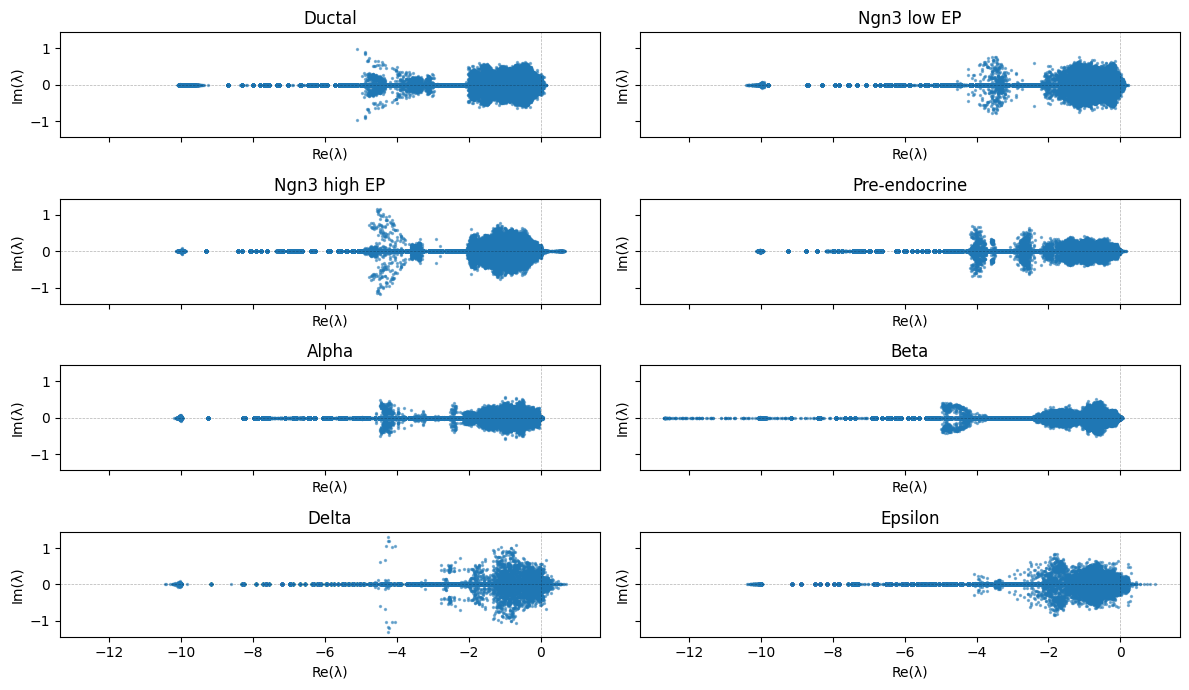

In [7]:
fig = sch.pl.plot_jacobian_eigenvalue_spectrum(
    adata, cluster_key=CLUSTER_KEY, order=ORDER, figsize=(12, 7))
plt.show()

## 3. Networks

The third reading treats each fitted $W$ as a weighted directed graph. $W$ is stored as
`W[target, regulator]`, so a gene's outgoing influence is the column sum of $|W|$, and that is
what `regulatory_out_strength` returns, summed over the cell-type networks.

Out-strength is also the filter that keeps a knockout screen honest: a gene with no outgoing
influence is a pure sink, and knocking it out cannot propagate no matter how highly it is
expressed. The perturbation tutorials use exactly this.

In [8]:
out_strength = sch.tl.regulatory_out_strength(adata, cluster_key=CLUSTER_KEY)
total = out_strength.sum()

print("strongest regulators, summed over the cell-type networks:\n")
print(out_strength.nlargest(12).round(1).to_string())
print()
for k in (5, 10, 20, 50):
    print(f"  the top {k:>2} regulators carry {out_strength.nlargest(k).sum() / total:6.1%} "
          f"of all out-strength")

strongest regulators, summed over the cell-type networks:

Hes1       12888.7
Ehf        10956.7
Pax6        2279.2
Zbtb7c      2096.8
Fev         2041.9
Etv1        1916.5
Neurod1     1771.8
Vdr         1530.2
Rest        1463.2
Hmgn3       1202.5
Pou6f2      1046.6
Rfx6        1041.3

  the top  5 regulators carry  48.2% of all out-strength
  the top 10 regulators carry  60.7% of all out-strength
  the top 20 regulators carry  73.8% of all out-strength
  the top 50 regulators carry  90.8% of all out-strength


The field is carried by a small minority of genes. That concentration is not imposed: nothing in
the fit asks for it. It follows from restricting regulation to transcription factors and then
letting the data decide which of them matter.

Next, how much the regulatory program actually differs between cell types.
`network_correlations` compares the fitted matrices pairwise.

In [9]:
t0 = time.time()
sch.tl.network_correlations(adata, cluster_key=CLUSTER_KEY)
sch.tl.compute_network_centrality(adata, cluster_key=CLUSTER_KEY)
print(f"network comparisons and centrality: {time.time() - t0:.1f} s")

pearson = adata.uns["scHopfield"]["network_correlations"]["pearson"]
pearson = pearson.reindex(index=ORDER, columns=ORDER)
pearson.round(2)

network comparisons and centrality: 19.8 s


,Ductal,Ngn3 low EP,Ngn3 high EP,Pre-endocrine,Alpha,Beta,Delta,Epsilon
Ductal,1.00,0.50,0.16,0.01,0.01,-0.00,0.00,0.01
Ngn3 low EP,0.50,1.00,0.26,0.02,0.00,-0.01,0.00,0.01
Ngn3 high EP,0.16,0.26,1.00,0.04,0.01,0.01,0.03,0.02
Pre-endocrine,0.01,0.02,0.04,1.00,0.84,0.86,0.82,0.92
Alpha,0.01,0.00,0.01,0.84,1.00,0.81,0.76,0.82
Beta,-0.00,-0.01,0.01,0.86,0.81,1.00,0.76,0.83
Delta,0.00,0.00,0.03,0.82,0.76,0.76,1.00,0.81
Epsilon,0.01,0.01,0.02,0.92,0.82,0.83,0.81,1.00


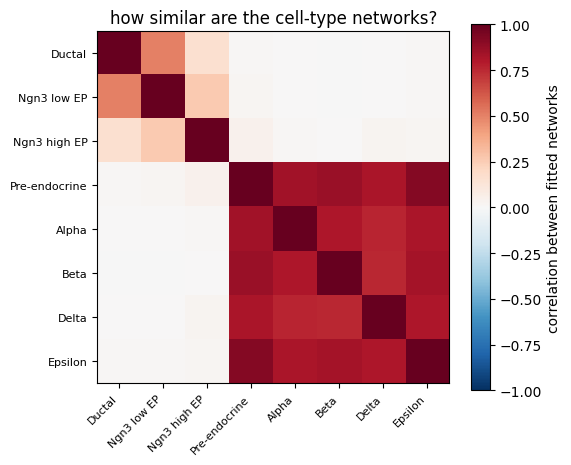

In [10]:
fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(pearson.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER, fontsize=8)
fig.colorbar(im, ax=ax, label="correlation between fitted networks")
ax.set_title("how similar are the cell-type networks?")
fig.tight_layout()
plt.show()

The matrix separates into two blocks with almost nothing between them. The progenitor networks
(Ductal and the two Ngn3 states) correlate weakly but positively with each other; the committed
and mature networks correlate strongly with each other; and a progenitor network against a mature
one is close to uncorrelated. That is a
statement about regulatory programs rather than about expression, and it is the reason one global
system reconstructs the velocity less well than eight cell-type systems do, as measured at the end
of Getting started.

Finally, the network of one cell type drawn directly.

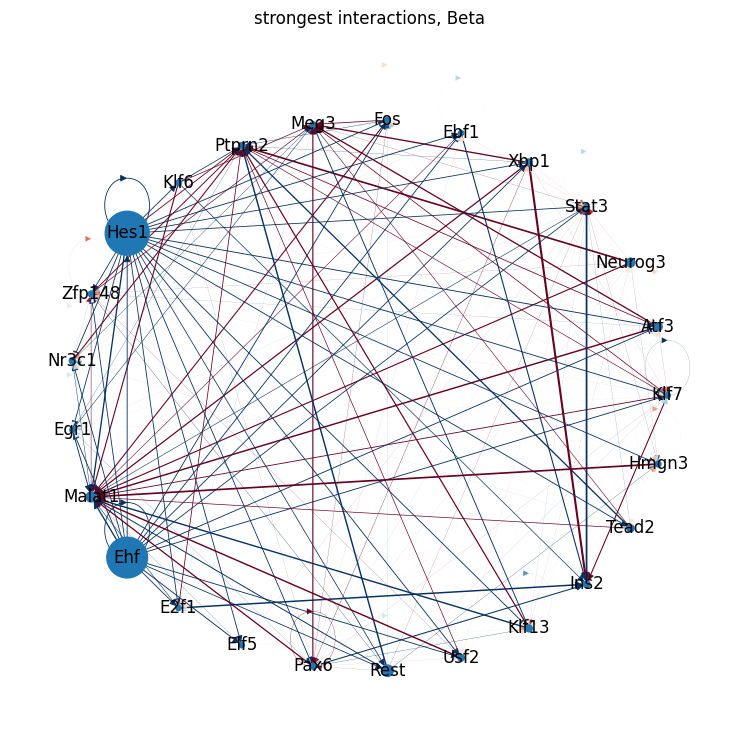

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
sch.pl.plot_grn_network(adata, cluster="Beta", cluster_key=CLUSTER_KEY, topn=25, ax=ax)
ax.set_title("strongest interactions, Beta")
fig.tight_layout()
plt.show()

## What this one dataset does not show

The energy reading generalizes across systems and the stability reading does not, but **that
claim is not made here and cannot be**. It is a comparison across seven datasets, and a single
dataset can only show what its own fit does. Everything above is one dataset, and it is offered
as an illustration of the three readings rather than as evidence for how they behave in general.
The cross-system comparison is reproduced by the figure code that ships with the repository, not
by this notebook.

Two things above **are** properties of this fit and are checkable by re-running it: the bias term
carries essentially none of the energy, and the count of unstable directions does not fall
monotonically along the developmental order.

## Where to go next

- **Why the structural scaffold matters** takes the near-zero bias term seriously and shows what
  an unrestricted fit does instead.
- **Single-gene knockouts** uses this fitted system to extrapolate to states that were never
  observed.